# Transfer Learning v2 — Mejora de modelos

En el notebook anterior (`TransferLearningImagen.ipynb`) los modelos preentrenados no superaron a la CNN from scratch. Identificamos dos causas principales:

1. **Preprocesado inadecuado para MobileNetV2** — su `preprocess_input` normaliza a [-1,1] y es muy sensible a la distribución de imágenes médicas en escala de grises replicada.
2. **Fine-Tuning limitado en VGG16** — solo se descongeló el block5. Descongelar también el block4 puede mejorar la adaptación al dominio.

En este notebook probamos **4 variantes** para intentar superar esos resultados:

| Experimento | Modelo | Cambio respecto a v1 |
|---|---|---|
| 1 | MobileNetV2 | Normalización simple [0,1] en lugar de `preprocess_input` |
| 2 | VGG16 | Fine-Tuning extendido: block4 + block5 |
| 3 | ResNet50 | Nuevo modelo con skip connections |
| 4 | DenseNet121 | Nuevo modelo, referencia en clasificación de radiografías |

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import models, layers, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, MobileNetV2, ResNet50, DenseNet121
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet50_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, RocCurveDisplay)
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

CLASSES     = ["NORMAL", "PNEUMONIA"]
INPUT_SHAPE = (224, 224, 3)
EPOCHS_FE   = 10
EPOCHS_FT   = 10

TensorFlow: 2.20.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ─── CARGAR DATOS ──────────────────────────────────────────────────────────
from google.colab import drive
import zipfile

drive.mount('/content/drive')

ZIP_PATH = "/content/drive/MyDrive/chest_xray_npy.zip"
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall("/content/chest_xray_npy")

SAVE_DIR = "/content/chest_xray_npy"

X_train = np.load(f"{SAVE_DIR}/X_train.npy")
y_train = np.load(f"{SAVE_DIR}/y_train.npy")
X_val   = np.load(f"{SAVE_DIR}/X_val.npy")
y_val   = np.load(f"{SAVE_DIR}/y_val.npy")
X_test  = np.load(f"{SAVE_DIR}/X_test.npy")
y_test  = np.load(f"{SAVE_DIR}/y_test.npy")

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

Mounted at /content/drive
Train: (5216, 224, 224) | Val: (16, 224, 224) | Test: (624, 224, 224)


In [ ]:
# ─── RGB + CLASS WEIGHTS ───────────────────────────────────────────────────
def to_rgb(X):
    if X.ndim == 3:
        X = X[..., np.newaxis]
    return np.repeat(X, 3, axis=-1).astype(np.float32)

X_train_rgb = to_rgb(X_train)
X_val_rgb   = to_rgb(X_val)
X_test_rgb  = to_rgb(X_test)

if X_train_rgb.max() <= 1.0:
    X_train_rgb = X_train_rgb * 255.0
    X_val_rgb   = X_val_rgb   * 255.0
    X_test_rgb  = X_test_rgb  * 255.0

print(f"RGB — Train: {X_train_rgb.shape} | Rango: [{X_train_rgb.min():.0f}, {X_train_rgb.max():.0f}]")

cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight_dict = dict(enumerate(cw))
print(f"Class weights: {class_weight_dict}")

RGB — Train: (5216, 224, 224, 3) | Rango: [0, 255]
Class weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


In [ ]:
# ─── HELPERS ───────────────────────────────────────────────────────────────

def make_generators(preprocess_fn, batch_size=32):
    train_gen = ImageDataGenerator(
        preprocessing_function=preprocess_fn,
        horizontal_flip=True,
        rotation_range=10,
        zoom_range=0.1,
        width_shift_range=0.05,
        height_shift_range=0.05,
        fill_mode='nearest'
    ).flow(X_train_rgb, y_train, batch_size=batch_size)

    val_gen = ImageDataGenerator(
        preprocessing_function=preprocess_fn
    ).flow(X_val_rgb, y_val, batch_size=batch_size, shuffle=False)

    return train_gen, val_gen


def plot_history(history, title):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, (metric, label) in zip(axes,
            [('accuracy', 'Accuracy'), ('loss', 'Loss'), ('auc', 'AUC-ROC')]):
        ax.plot(history.history[metric],          label='Train', color='steelblue')
        ax.plot(history.history[f'val_{metric}'], label='Val',   color='tomato')
        ax.set_title(label, fontsize=12)
        ax.set_xlabel('Época')
        ax.legend()
        ax.grid(alpha=0.3)
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


results_v2 = {}

def evaluate_model(model, X_input, model_name):
    y_score = model.predict(X_input).flatten()
    y_pred  = (y_score > 0.5).astype(int)
    cm      = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    auc  = roc_auc_score(y_test, y_score)
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)

    print(f"\n{'='*55}")
    print(f"  {model_name} — TEST SET")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, target_names=CLASSES))
    print(f"AUC-ROC      : {auc:.4f}")
    print(f"Sensibilidad : {sens:.4f}  (Recall PNEUMONIA)")
    print(f"Especificidad: {spec:.4f}  (Recall NORMAL)")
    print(f"Falsos Negativos: {fn}")

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[0],
                xticklabels=CLASSES, yticklabels=CLASSES,
                cmap='Blues', linewidths=0.5)
    axes[0].set_title(f"Confusión — {model_name}", fontsize=12)
    axes[0].set_xlabel("Predicho"); axes[0].set_ylabel("Real")
    RocCurveDisplay.from_predictions(y_test, y_score, ax=axes[1],
                                     name=model_name, color='steelblue')
    axes[1].plot([0, 1], [0, 1], 'k--')
    axes[1].set_title(f"ROC — {model_name}", fontsize=12)
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    results_v2[model_name] = {
        'accuracy': (tp + tn) / len(y_test),
        'auc': auc, 'sens': sens, 'spec': spec, 'fn': fn
    }
    return y_score


def run_transfer_learning(base_model, preprocess_fn, model_name,
                          head_units=128, fe_lr=1e-4, ft_lr=1e-5,
                          freeze_fn=None):
    """Ejecuta Feature Extraction + Fine-Tuning para un backbone dado.

    freeze_fn(base_model): función que aplica la política de descongelado para FT.
    Si es None, descongela las últimas 30 capas por defecto.
    """
    train_gen, val_gen = make_generators(preprocess_fn)

    # ── Fase 1: Feature Extraction ────────────────────────────────────
    base_model.trainable = False
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(head_units, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ], name=f'model_{model_name}')

    model.compile(
        optimizer=optimizers.Adam(fe_lr),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Recall(name='recall')]
    )

    cbs_fe = [
        callbacks.EarlyStopping(monitor='val_loss', patience=5,
                                restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=3, min_lr=1e-7, verbose=1),
    ]

    print(f"\n{'='*60}")
    print(f"  {model_name} — FEATURE EXTRACTION")
    print(f"  Params totales: {model.count_params():,} | Entrenables: "
          f"{sum(np.prod(v.shape) for v in model.trainable_variables):,}")
    print(f"{'='*60}")

    hist_fe = model.fit(train_gen, epochs=EPOCHS_FE, validation_data=val_gen,
                        class_weight=class_weight_dict, callbacks=cbs_fe, verbose=1)
    plot_history(hist_fe, f"{model_name} — Feature Extraction")
    score_fe = evaluate_model(model, X_test_rgb, f"{model_name} FE")

    # ── Fase 2: Fine-Tuning ────────────────────────────────────────────
    if freeze_fn is not None:
        freeze_fn(base_model)
    else:
        base_model.trainable = True
        for layer in base_model.layers[:-30]:
            layer.trainable = False

    n_train = sum(l.trainable for l in base_model.layers)
    print(f"\nCapas entrenables en backbone: {n_train}/{len(base_model.layers)}")

    model.compile(
        optimizer=optimizers.Adam(ft_lr),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Recall(name='recall')]
    )

    cbs_ft = [
        callbacks.EarlyStopping(monitor='val_loss', patience=5,
                                restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=3, min_lr=1e-8, verbose=1),
    ]

    print(f"\n{'='*60}")
    print(f"  {model_name} — FINE-TUNING")
    print(f"{'='*60}")

    hist_ft = model.fit(train_gen, epochs=EPOCHS_FT, validation_data=val_gen,
                        class_weight=class_weight_dict, callbacks=cbs_ft, verbose=1)
    plot_history(hist_ft, f"{model_name} — Fine-Tuning")
    score_ft = evaluate_model(model, X_test_rgb, f"{model_name} FT")

    return score_fe, score_ft

## Experimento 1 — MobileNetV2 con normalización simple

**Hipótesis**: el bajo rendimiento de MobileNetV2 en v1 (AUC 0.69) se debe a que `mobilenetv2_preprocess` normaliza a [-1, 1] y es muy sensible a la distribución de imágenes médicas en escala de grises replicada. Sustituimos el preprocesado por una normalización simple a [0, 1], mucho más compatible con estas imágenes.

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

  MobileNetV2_v2 — FEATURE EXTRACTION
  Params totales: 2,422,081 | Entrenables: 164,097
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 95s 450ms/step - accuracy: 0.8332 - auc: 0.9170 - loss: 0.3664 - recall: 0.8390 - val_accuracy: 0.8750 - val_auc: 0.9531 - val_loss: 0.2891 - val_recall: 0.7500 - learning_rate: 1.0000e-04
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 59s 361ms/step - accuracy: 0.9179 - auc: 0.9762 - loss: 0.2000 - recall: 0.9125 - val_accuracy: 0.8750 - val_auc: 0.9766 - val_loss: 0.2601 - val_recall: 0.7500 - learning_rate: 1.0000e-04
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 59s 363ms/step - accuracy: 0.9308 - auc: 0.9820 - loss: 0.1714 - recall: 0.9236 - val_accuracy: 0.8750 - val_auc: 0.9688 - val_loss: 0.2417 - val_recall: 0.7500 - learning_rate: 1.0000e-04
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 59s 358ms/step - accuracy: 0.9340 - auc: 0.9843 - loss: 0.1592 - recall: 0.9280 - val_accuracy: 0.8750 - val_auc: 0.9844 - val_loss: 0

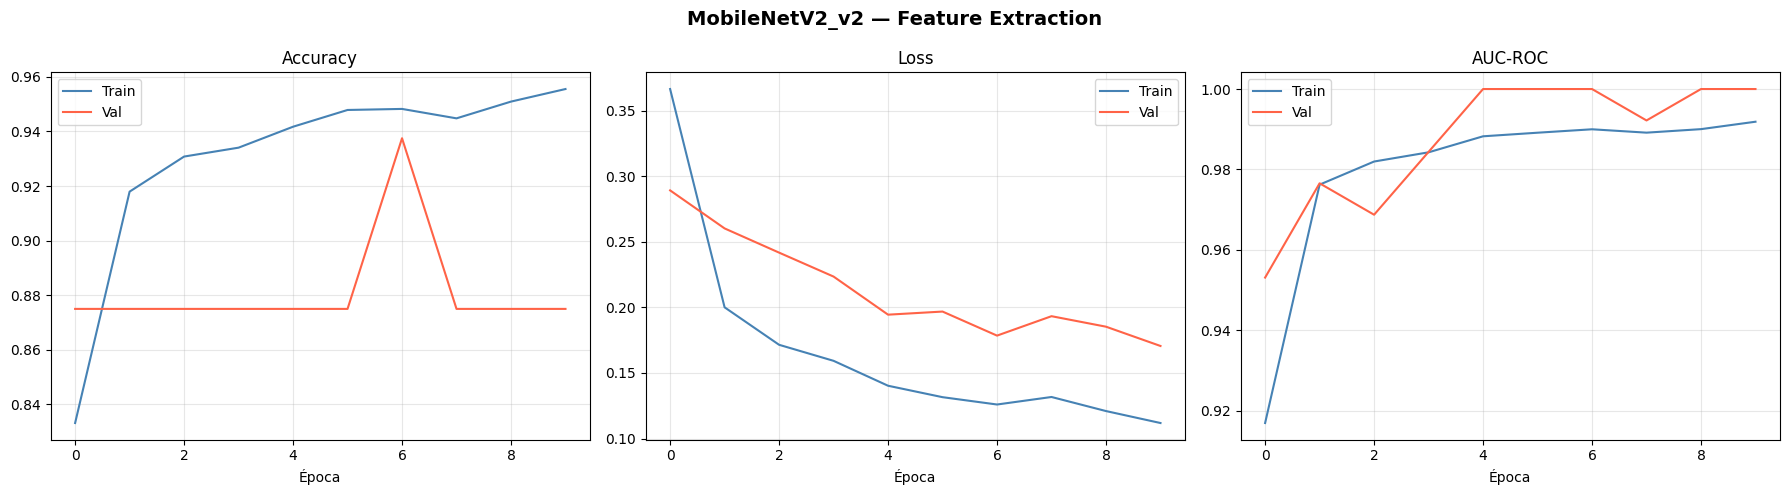

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 323ms/step

  MobileNetV2_v2 FE — TEST SET
              precision    recall  f1-score   support

      NORMAL       1.00      0.01      0.02       234
   PNEUMONIA       0.63      1.00      0.77       390

    accuracy                           0.63       624
   macro avg       0.81      0.50      0.39       624
weighted avg       0.77      0.63      0.49       624

AUC-ROC      : 0.5897
Sensibilidad : 1.0000  (Recall PNEUMONIA)
Especificidad: 0.0085  (Recall NORMAL)
Falsos Negativos: 0


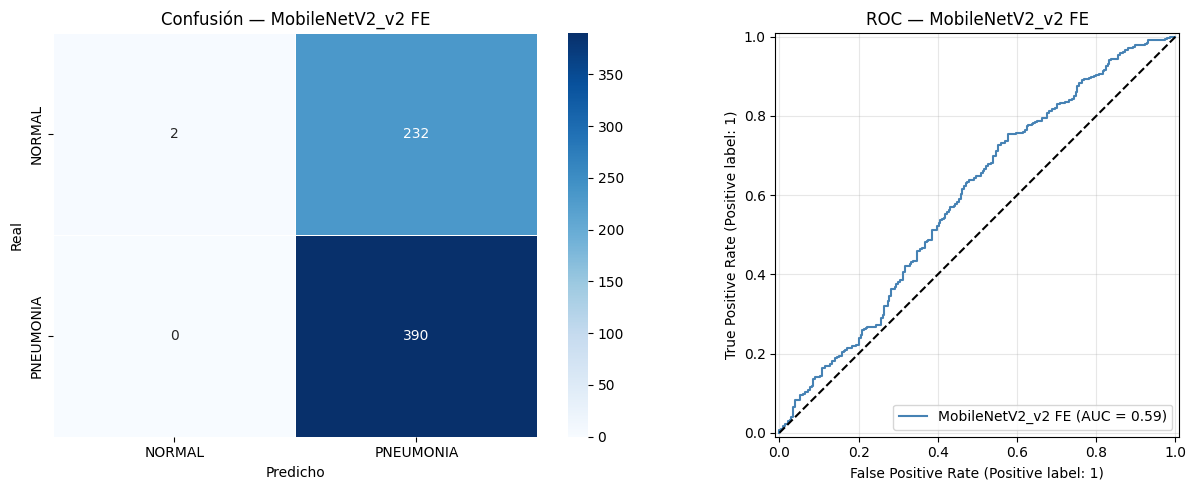


Capas entrenables en backbone: 30/154

  MobileNetV2_v2 — FINE-TUNING
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 87s 418ms/step - accuracy: 0.9287 - auc: 0.9758 - loss: 0.2044 - recall: 0.9352 - val_accuracy: 0.9375 - val_auc: 0.9844 - val_loss: 0.1516 - val_recall: 1.0000 - learning_rate: 2.0000e-05
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 61s 372ms/step - accuracy: 0.9450 - auc: 0.9865 - loss: 0.1411 - recall: 0.9396 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 0.1398 - val_recall: 1.0000 - learning_rate: 2.0000e-05
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 62s 382ms/step - accuracy: 0.9546 - auc: 0.9911 - loss: 0.1096 - recall: 0.9505 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 0.1819 - val_recall: 1.0000 - learning_rate: 2.0000e-05
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 60s 369ms/step - accuracy: 0.9634 - auc: 0.9930 - loss: 0.0950 - recall: 0.9582 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 0.1458 - val_recall: 0.8750 - learning_rate: 2.0000e-05
Epoch 5/10
16

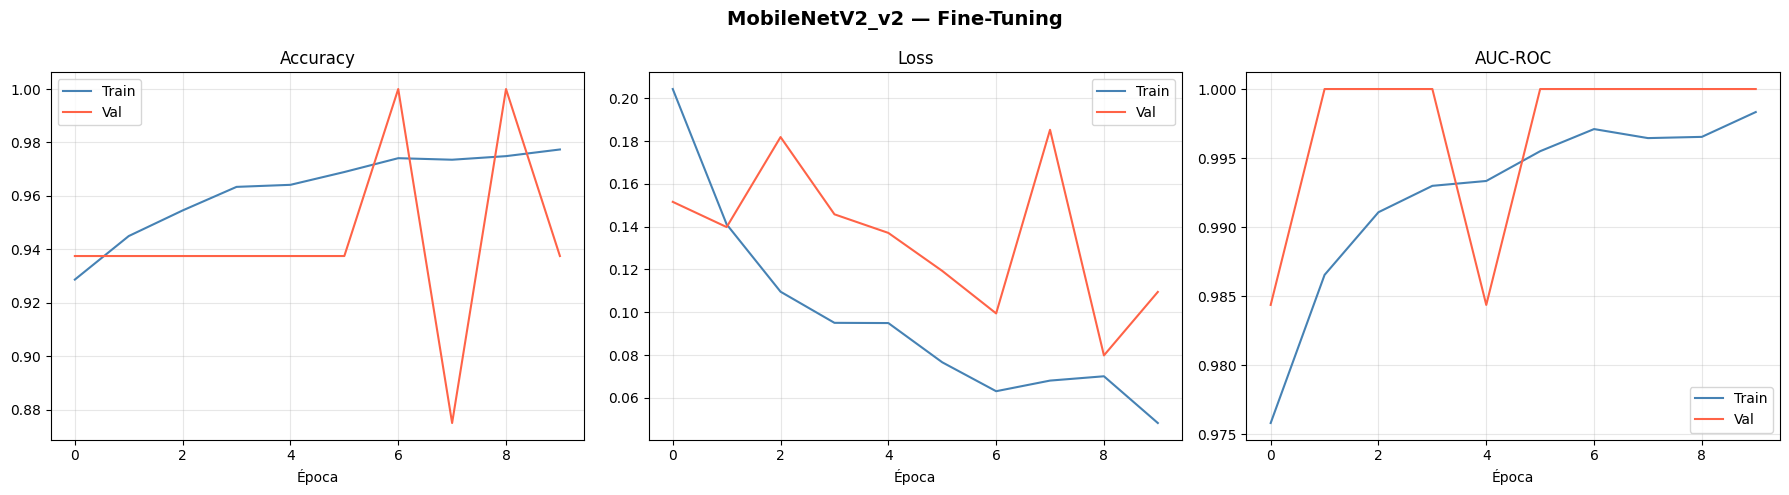

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 254ms/step

  MobileNetV2_v2 FT — TEST SET
              precision    recall  f1-score   support

      NORMAL       0.51      0.11      0.18       234
   PNEUMONIA       0.64      0.94      0.76       390

    accuracy                           0.63       624
   macro avg       0.57      0.52      0.47       624
weighted avg       0.59      0.63      0.54       624

AUC-ROC      : 0.6352
Sensibilidad : 0.9385  (Recall PNEUMONIA)
Especificidad: 0.1068  (Recall NORMAL)
Falsos Negativos: 24


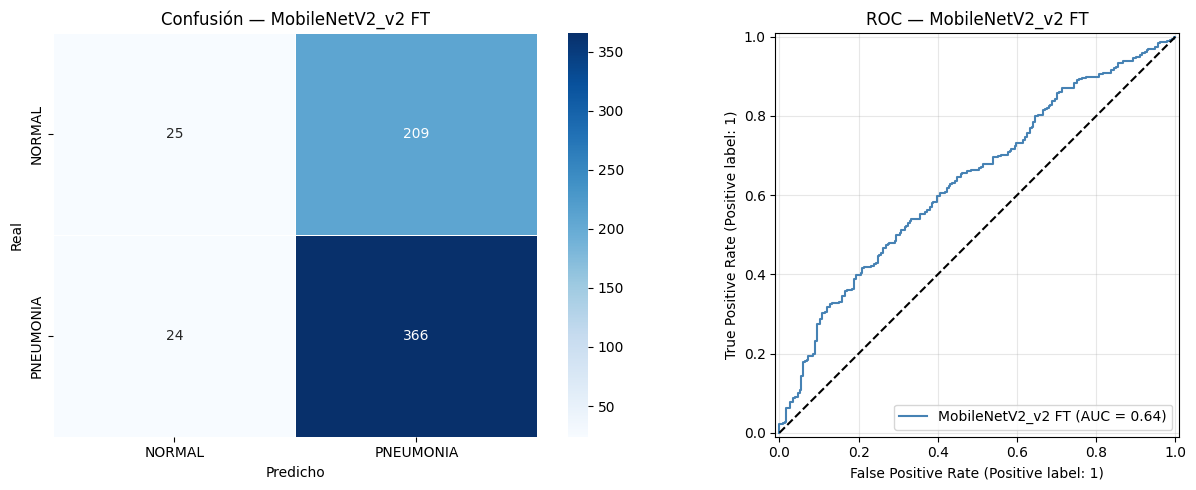

In [ ]:
# Normalización simple [0, 1] en lugar de mobilenetv2_preprocess
def simple_normalize(x):
    return x / 255.0

def freeze_mobilenet_last30(base):
    base.trainable = True
    for layer in base.layers[:-30]:
        layer.trainable = False

base_mob2 = MobileNetV2(weights='imagenet', include_top=False, input_shape=INPUT_SHAPE)

score_mob2_fe, score_mob2_ft = run_transfer_learning(
    base_model   = base_mob2,
    preprocess_fn= simple_normalize,
    model_name   = 'MobileNetV2_v2',
    head_units   = 128,
    fe_lr        = 1e-4,
    ft_lr        = 2e-5,
    freeze_fn    = freeze_mobilenet_last30
)

## Experimento 2 — VGG16 con Fine-Tuning extendido (block4 + block5)

**Hipótesis**: en v1 solo descongelamos block5 (4 capas, ~7.08M parámetros). Descongelar también block4 expone más filtros al ajuste sobre datos médicos. El riesgo es mayor overfitting, por eso usamos un learning rate aún más bajo (5e-6).

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

  VGG16_v2 — FEATURE EXTRACTION
  Params totales: 14,846,273 | Entrenables: 131,585
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 90s 457ms/step - accuracy: 0.7329 - auc: 0.8048 - loss: 0.9490 - recall: 0.7249 - val_accuracy: 0.8750 - val_auc: 1.0000 - val_loss: 0.3428 - val_recall: 0.7500 - learning_rate: 1.0000e-04
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 68s 416ms/step - accuracy: 0.8748 - auc: 0.9432 - loss: 0.3811 - recall: 0.8723 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 0.1434 - val_recall: 0.8750 - learning_rate: 1.0000e-04
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 66s 406ms/step - accuracy: 0.8947 - auc: 0.9571 - loss: 0.2946 - recall: 0.8934 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 0.1853 - val_recall: 0.8750 - learning_rate: 1.0000e-04
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 67s 407ms/step - accuracy: 0.9183 - auc: 0.9727 - loss: 0.2172 - recall: 0.9156 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 0.13

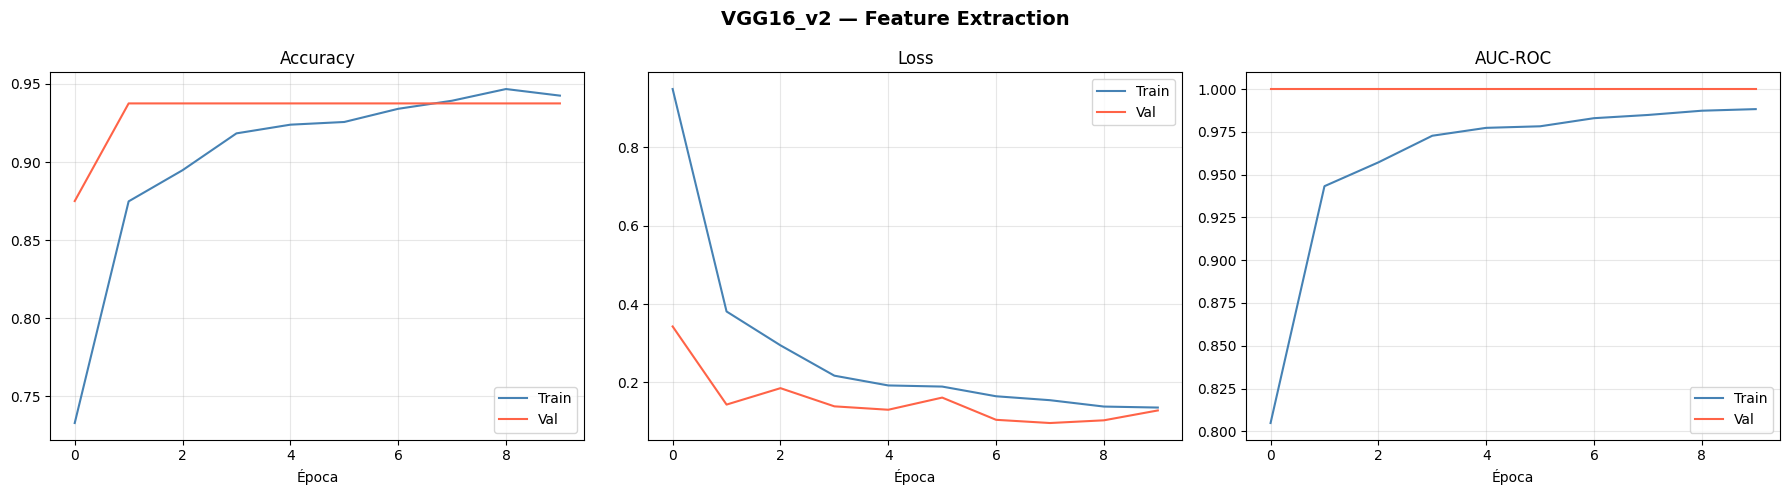

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 189ms/step

  VGG16_v2 FE — TEST SET
              precision    recall  f1-score   support

      NORMAL       0.92      0.46      0.61       234
   PNEUMONIA       0.75      0.97      0.85       390

    accuracy                           0.78       624
   macro avg       0.83      0.72      0.73       624
weighted avg       0.81      0.78      0.76       624

AUC-ROC      : 0.8921
Sensibilidad : 0.9744  (Recall PNEUMONIA)
Especificidad: 0.4615  (Recall NORMAL)
Falsos Negativos: 10


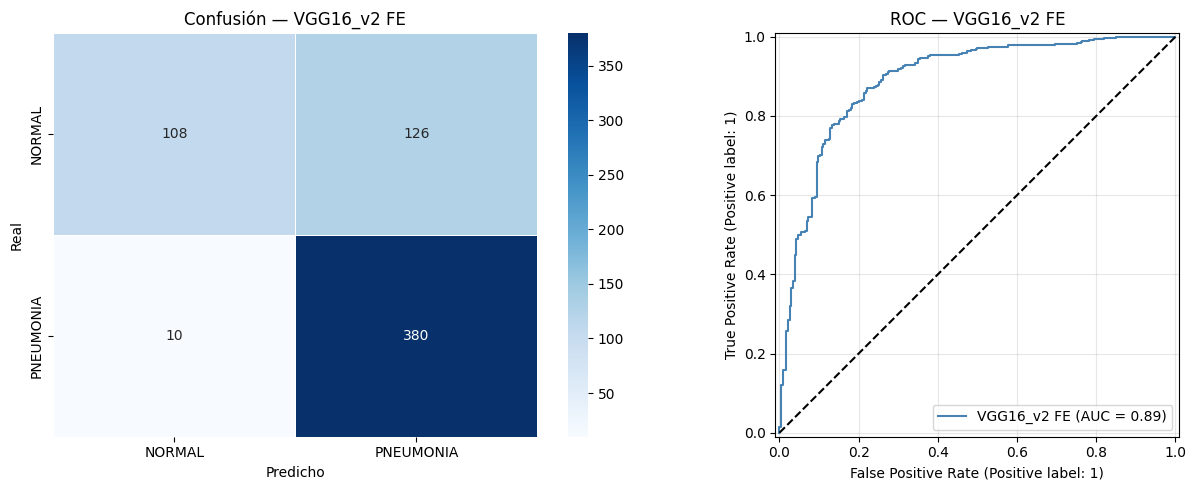


Capas entrenables en backbone: 8/19

  VGG16_v2 — FINE-TUNING
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 92s 460ms/step - accuracy: 0.9471 - auc: 0.9888 - loss: 0.1335 - recall: 0.9458 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 0.0860 - val_recall: 0.8750 - learning_rate: 5.0000e-06
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 75s 458ms/step - accuracy: 0.9613 - auc: 0.9934 - loss: 0.0974 - recall: 0.9592 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0446 - val_recall: 1.0000 - learning_rate: 5.0000e-06
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 75s 460ms/step - accuracy: 0.9734 - auc: 0.9963 - loss: 0.0699 - recall: 0.9708 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0208 - val_recall: 1.0000 - learning_rate: 5.0000e-06
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 75s 460ms/step - accuracy: 0.9728 - auc: 0.9966 - loss: 0.0665 - recall: 0.9716 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 0.1321 - val_recall: 0.8750 - learning_rate: 5.0000e-06
Epoch 5/10
163/163 ━━

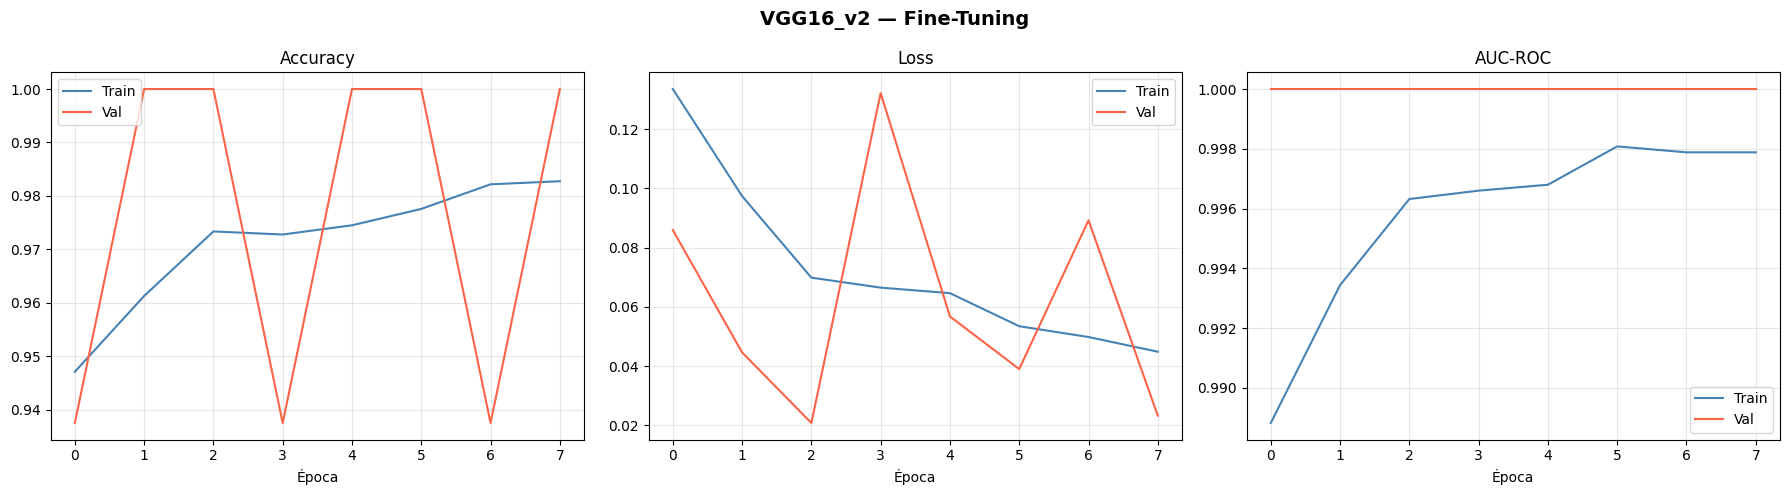

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 190ms/step

  VGG16_v2 FT — TEST SET
              precision    recall  f1-score   support

      NORMAL       0.94      0.46      0.61       234
   PNEUMONIA       0.75      0.98      0.85       390

    accuracy                           0.79       624
   macro avg       0.84      0.72      0.73       624
weighted avg       0.82      0.79      0.76       624

AUC-ROC      : 0.9234
Sensibilidad : 0.9821  (Recall PNEUMONIA)
Especificidad: 0.4573  (Recall NORMAL)
Falsos Negativos: 7


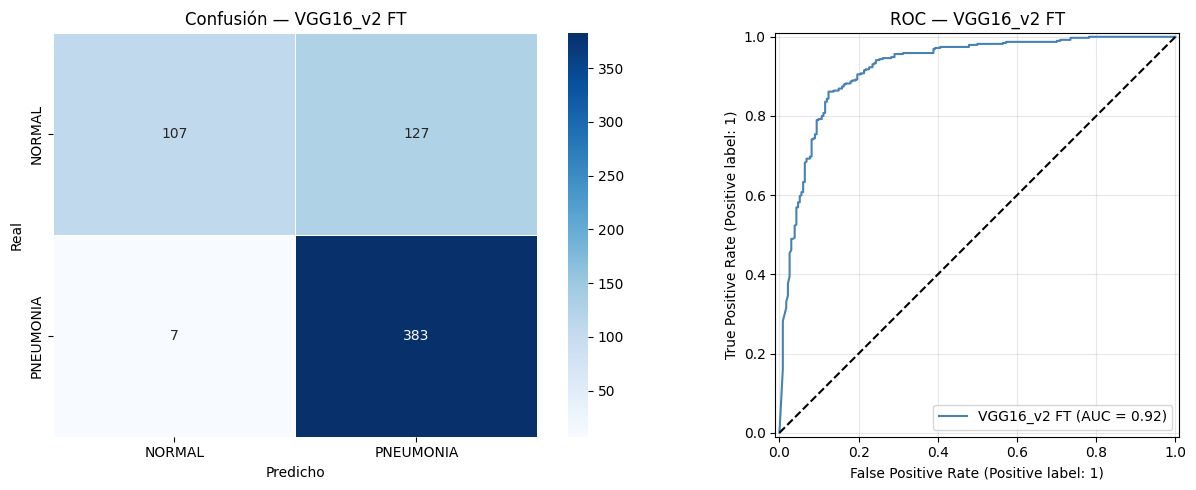

In [ ]:
def freeze_vgg_block4_block5(base):
    base.trainable = True
    for layer in base.layers:
        layer.trainable = (layer.name.startswith('block4') or
                           layer.name.startswith('block5'))

base_vgg2 = VGG16(weights='imagenet', include_top=False, input_shape=INPUT_SHAPE)

score_vgg2_fe, score_vgg2_ft = run_transfer_learning(
    base_model   = base_vgg2,
    preprocess_fn= vgg16_preprocess,
    model_name   = 'VGG16_v2',
    head_units   = 256,
    fe_lr        = 1e-4,
    ft_lr        = 5e-6,       # más bajo que v1 por descongelar más capas
    freeze_fn    = freeze_vgg_block4_block5
)

## Experimento 3 — ResNet50

ResNet50 introduce **conexiones residuales (skip connections)** que permiten al gradiente fluir directamente a capas anteriores, lo que facilita el fine-tuning profundo y reduce el riesgo de vanishing gradient. Su arquitectura modular en bloques residuales (`conv2`–`conv5`) permite un control preciso de qué capas descongelar.

Para fine-tuning descongelamos el último bloque residual completo (`conv5`), que corresponde a los filtros más especializados y abstractos.

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

  ResNet50 — FEATURE EXTRACTION
  Params totales: 24,112,513 | Entrenables: 524,801
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 84s 423ms/step - accuracy: 0.8850 - auc: 0.9581 - loss: 0.2612 - recall: 0.8797 - val_accuracy: 0.8750 - val_auc: 1.0000 - val_loss: 0.2650 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 64s 393ms/step - accuracy: 0.9285 - auc: 0.9806 - loss: 0.1755 - recall: 0.9259 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 0.1478 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 63s 386ms/step - accuracy: 0.9454 - auc: 0.9881 - loss: 0.1352 - recall: 0.9409 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.1035 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 64s 392ms/step - accuracy: 0.9496 - auc: 0.9906 - loss: 0.1203 - recall: 0.9455 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.11

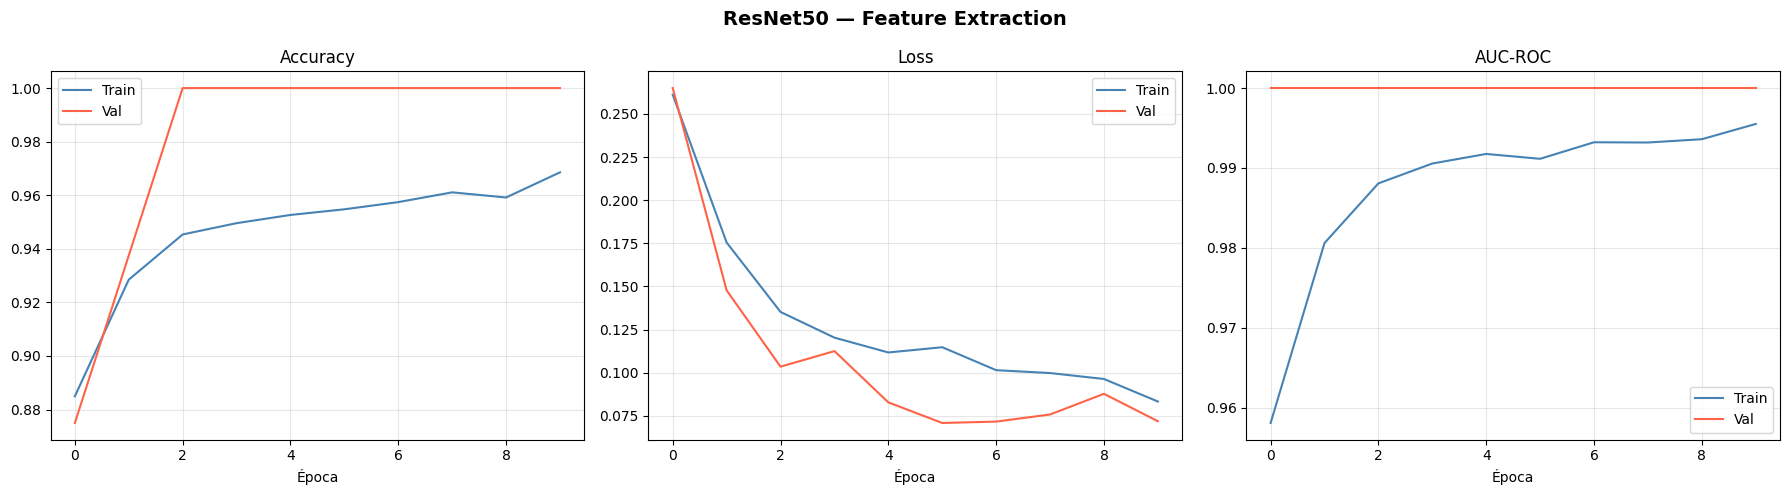

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 280ms/step

  ResNet50 FE — TEST SET
              precision    recall  f1-score   support

      NORMAL       0.80      0.92      0.85       234
   PNEUMONIA       0.95      0.86      0.90       390

    accuracy                           0.88       624
   macro avg       0.87      0.89      0.88       624
weighted avg       0.89      0.88      0.88       624

AUC-ROC      : 0.9517
Sensibilidad : 0.8615  (Recall PNEUMONIA)
Especificidad: 0.9188  (Recall NORMAL)
Falsos Negativos: 54


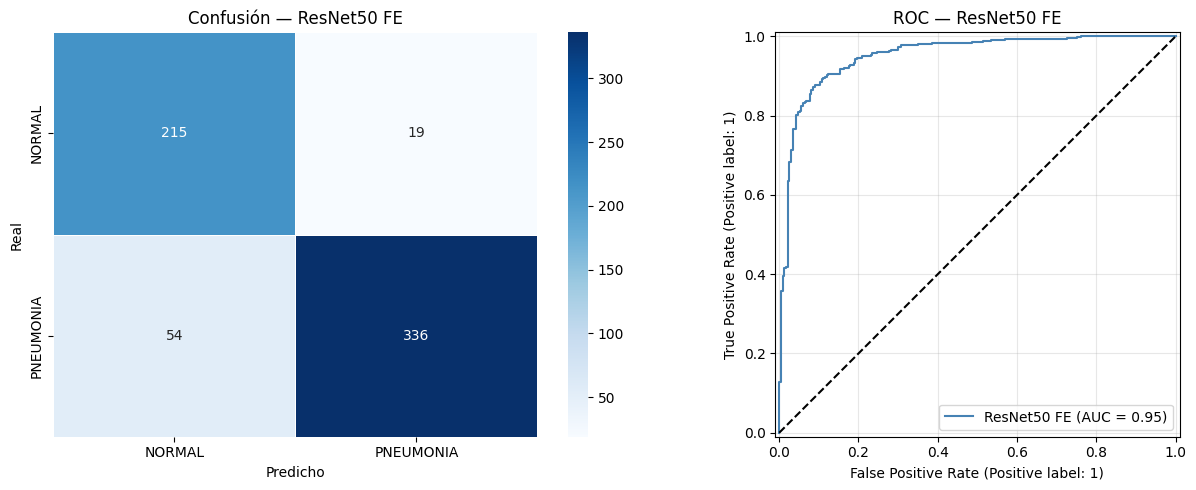


Capas entrenables en backbone: 32/175

  ResNet50 — FINE-TUNING
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 94s 440ms/step - accuracy: 0.9434 - auc: 0.9886 - loss: 0.1355 - recall: 0.9363 - val_accuracy: 0.8750 - val_auc: 1.0000 - val_loss: 0.2844 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 68s 417ms/step - accuracy: 0.9634 - auc: 0.9946 - loss: 0.0912 - recall: 0.9605 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 0.1522 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 67s 410ms/step - accuracy: 0.9724 - auc: 0.9963 - loss: 0.0737 - recall: 0.9714 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 0.0964 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 67s 412ms/step - accuracy: 0.9772 - auc: 0.9971 - loss: 0.0627 - recall: 0.9739 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 0.1169 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 5/10
163/163 

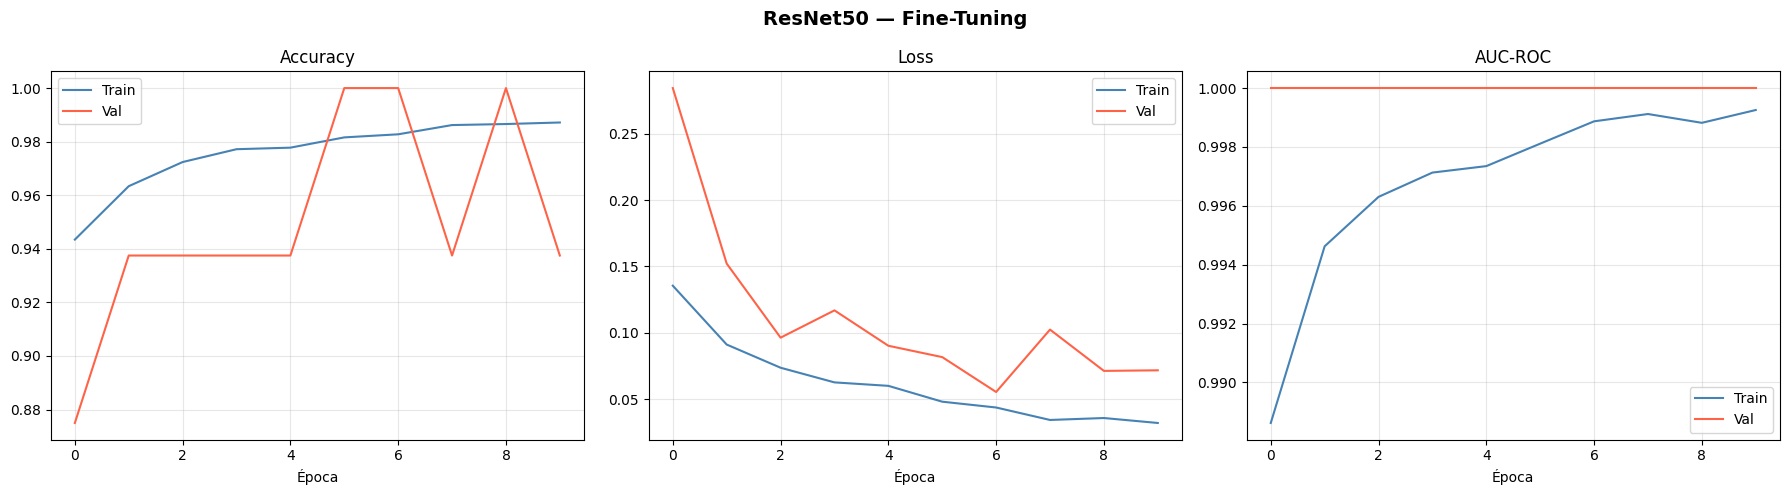

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 292ms/step

  ResNet50 FT — TEST SET
              precision    recall  f1-score   support

      NORMAL       0.88      0.86      0.87       234
   PNEUMONIA       0.92      0.93      0.92       390

    accuracy                           0.90       624
   macro avg       0.90      0.90      0.90       624
weighted avg       0.90      0.90      0.90       624

AUC-ROC      : 0.9555
Sensibilidad : 0.9282  (Recall PNEUMONIA)
Especificidad: 0.8632  (Recall NORMAL)
Falsos Negativos: 28


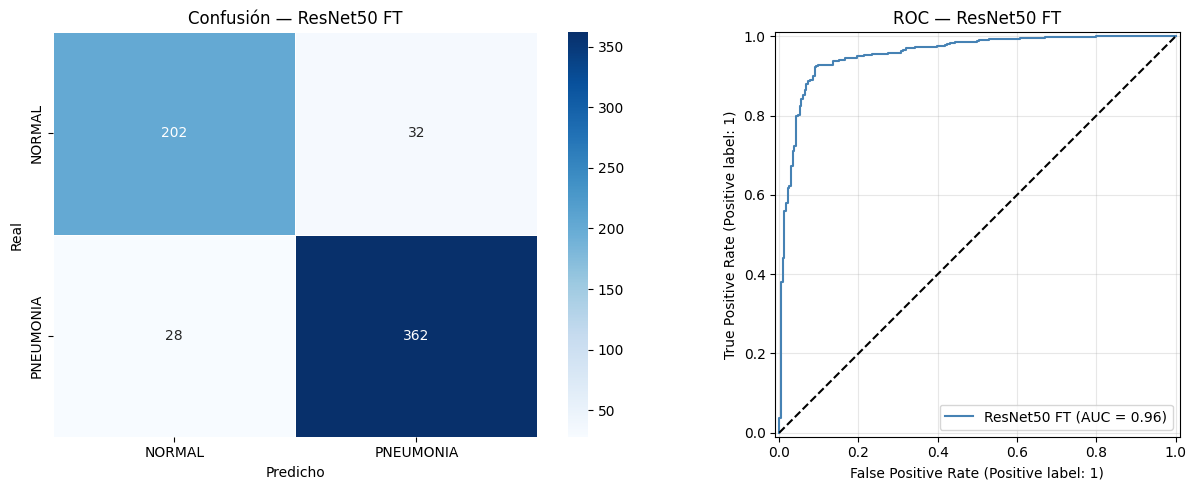

In [ ]:
def freeze_resnet_conv5(base):
    """Descongela solo el último bloque residual (conv5_block*)."""
    base.trainable = True
    for layer in base.layers:
        layer.trainable = 'conv5' in layer.name

base_res = ResNet50(weights='imagenet', include_top=False, input_shape=INPUT_SHAPE)

score_res_fe, score_res_ft = run_transfer_learning(
    base_model   = base_res,
    preprocess_fn= resnet50_preprocess,
    model_name   = 'ResNet50',
    head_units   = 256,
    fe_lr        = 1e-4,
    ft_lr        = 1e-5,
    freeze_fn    = freeze_resnet_conv5
)

## Experimento 4 — DenseNet121

DenseNet121 conecta cada capa con **todas las capas anteriores** dentro de un bloque denso, lo que favorece la reutilización de features y reduce el número total de parámetros. Es la arquitectura usada en **CheXNet** (Stanford, 2017), el primer sistema de clasificación de radiografías de tórax que superó a radiólogos humanos en detección de neumonía.

Para fine-tuning descongelamos las últimas 50 capas, que corresponden al último bloque denso y las capas de normalización finales.

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

  DenseNet121 — FEATURE EXTRACTION
  Params totales: 7,300,161 | Entrenables: 262,657
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 111s 497ms/step - accuracy: 0.7987 - auc: 0.8944 - loss: 0.4103 - recall: 0.7905 - val_accuracy: 0.8750 - val_auc: 0.9844 - val_loss: 0.2477 - val_recall: 0.8750 - learning_rate: 1.0000e-04
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 66s 402ms/step - accuracy: 0.9114 - auc: 0.9687 - loss: 0.2272 - recall: 0.9055 - val_accuracy: 0.8750 - val_auc: 0.9844 - val_loss: 0.2245 - val_recall: 0.8750 - learning_rate: 1.0000e-04
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 63s 388ms/step - accuracy: 0.9291 - auc: 0.9807 - loss: 0.1776 - recall: 0.9228 - val_accuracy: 0.9375 - val_auc: 0.9844 - val_loss: 0.2375 - val_recall: 0.8750 - learning_rate: 1.0000e-04
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 66s 406ms/step - accuracy: 0.9270 - auc: 0.9788 - loss: 0.1828 - recall: 0.9221 - val_accuracy: 0.9375 - val_auc: 0.9844 - val_loss: 0

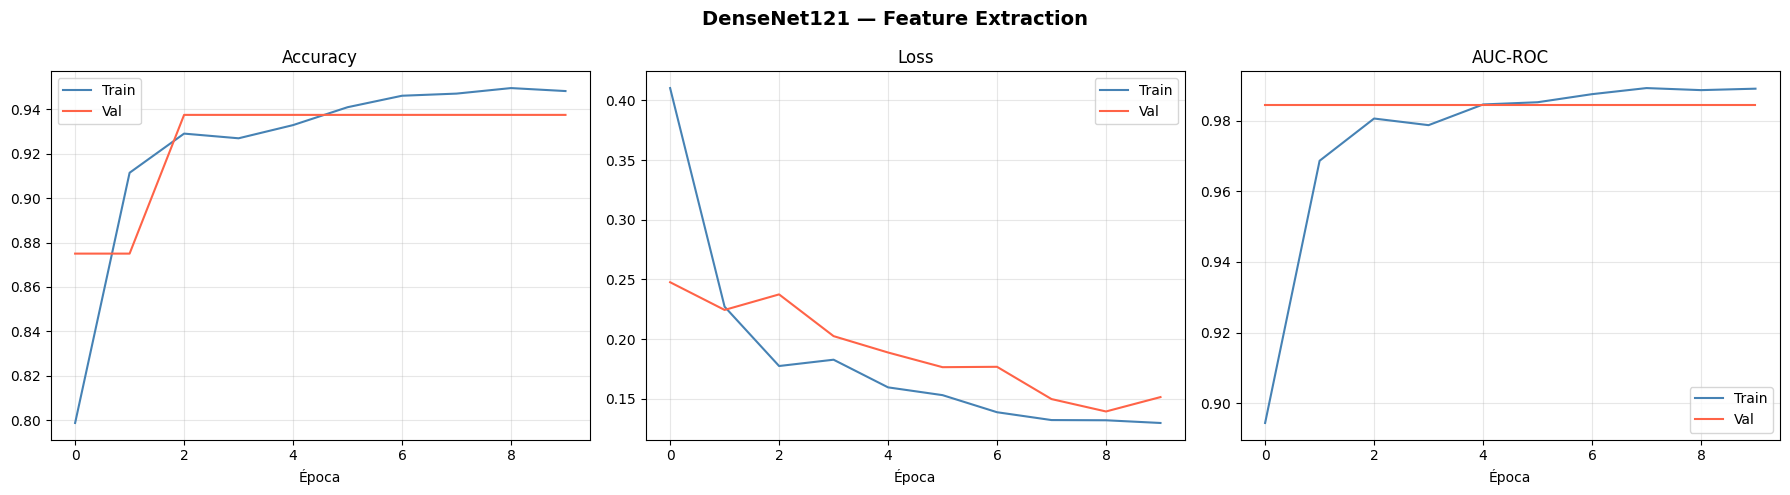

20/20 ━━━━━━━━━━━━━━━━━━━━ 27s 742ms/step

  DenseNet121 FE — TEST SET
              precision    recall  f1-score   support

      NORMAL       0.00      0.00      0.00       234
   PNEUMONIA       0.62      1.00      0.77       390

    accuracy                           0.62       624
   macro avg       0.31      0.50      0.38       624
weighted avg       0.39      0.62      0.48       624

AUC-ROC      : 0.6044
Sensibilidad : 1.0000  (Recall PNEUMONIA)
Especificidad: 0.0000  (Recall NORMAL)
Falsos Negativos: 0


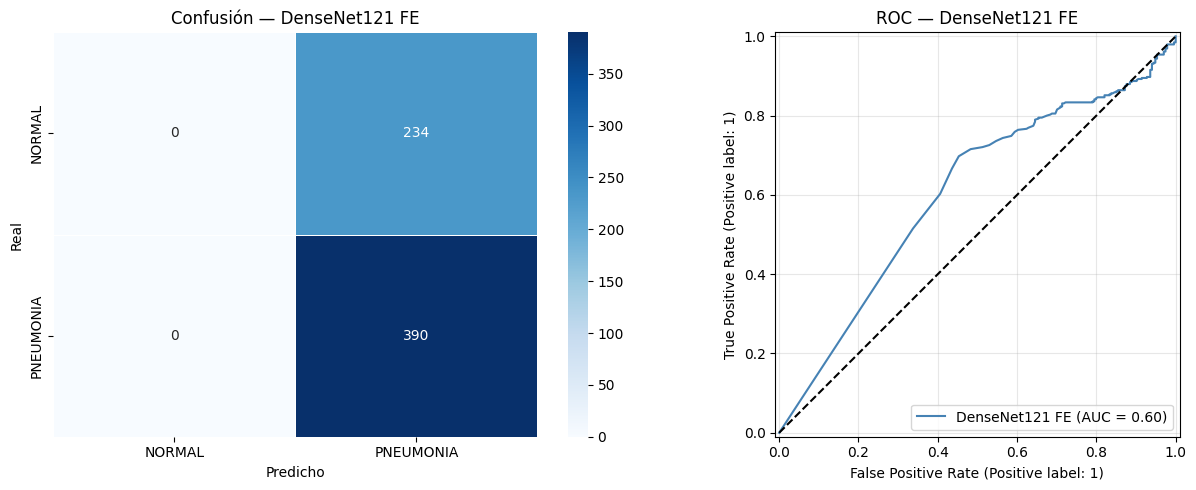


Capas entrenables en backbone: 50/427

  DenseNet121 — FINE-TUNING
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 118s 476ms/step - accuracy: 0.9306 - auc: 0.9742 - loss: 0.2482 - recall: 0.9608 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 0.1819 - val_recall: 0.8750 - learning_rate: 1.0000e-05
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 66s 401ms/step - accuracy: 0.9363 - auc: 0.9830 - loss: 0.1639 - recall: 0.9329 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 0.1569 - val_recall: 0.8750 - learning_rate: 1.0000e-05
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 66s 407ms/step - accuracy: 0.9456 - auc: 0.9876 - loss: 0.1394 - recall: 0.9412 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 0.1290 - val_recall: 0.8750 - learning_rate: 1.0000e-05
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 64s 393ms/step - accuracy: 0.9511 - auc: 0.9898 - loss: 0.1216 - recall: 0.9461 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 0.1131 - val_recall: 0.8750 - learning_rate: 1.0000e-05
Epoch 5/10
163/

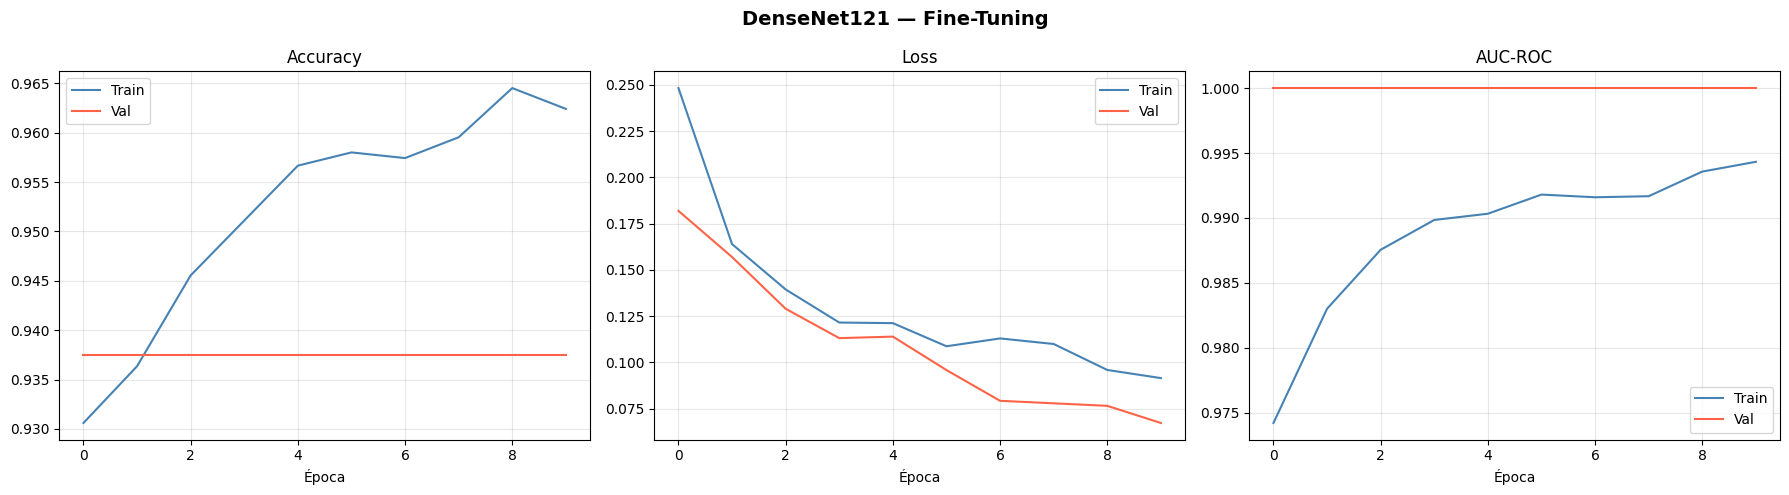

20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 768ms/step

  DenseNet121 FT — TEST SET
              precision    recall  f1-score   support

      NORMAL       0.00      0.00      0.00       234
   PNEUMONIA       0.62      1.00      0.77       390

    accuracy                           0.62       624
   macro avg       0.31      0.50      0.38       624
weighted avg       0.39      0.62      0.48       624

AUC-ROC      : 0.6186
Sensibilidad : 1.0000  (Recall PNEUMONIA)
Especificidad: 0.0000  (Recall NORMAL)
Falsos Negativos: 0


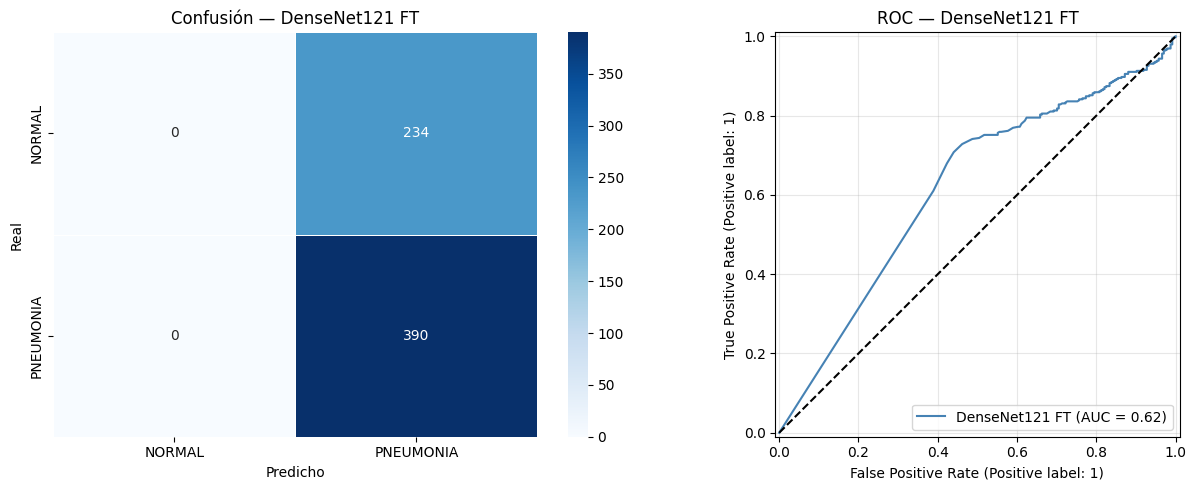

In [ ]:
def freeze_densenet_last50(base):
    """Descongela las últimas 50 capas (último bloque denso)."""
    base.trainable = True
    for layer in base.layers[:-50]:
        layer.trainable = False

base_dense = DenseNet121(weights='imagenet', include_top=False, input_shape=INPUT_SHAPE)

score_dense_fe, score_dense_ft = run_transfer_learning(
    base_model   = base_dense,
    preprocess_fn= densenet_preprocess,
    model_name   = 'DenseNet121',
    head_units   = 256,
    fe_lr        = 1e-4,
    ft_lr        = 1e-5,
    freeze_fn    = freeze_densenet_last50
)

## Comparación final — todos los modelos


Modelo                                Accuracy  AUC-ROC  Sensib.  Especif.    FN
────────────────────────────────────────────────────────────────────────────────
CNN v1 (from scratch)                   0.9000   0.9555   0.9359    0.8376    25
VGG16 FE (v1)                           0.8237   0.8820   0.8462    0.7863    60
VGG16 FT block5 (v1)                    0.8253   0.8816   0.8692    0.7521    51
MobileNetV2 FE preprocess (v1)          0.5753   0.6974   0.4487    0.7863   215
MobileNetV2 FT preprocess (v1)          0.6202   0.6898   0.5667    0.7094   169
────────────────────────────────────────────────────────────────────────────────
MobileNetV2_v2 FE                       0.6282   0.5897   1.0000    0.0085     0
MobileNetV2_v2 FT                       0.6266   0.6352   0.9385    0.1068    24
VGG16_v2 FE                             0.7821   0.8921   0.9744    0.4615    10
VGG16_v2 FT                             0.7853   0.9234   0.9821    0.4573     7
ResNet50 FE                

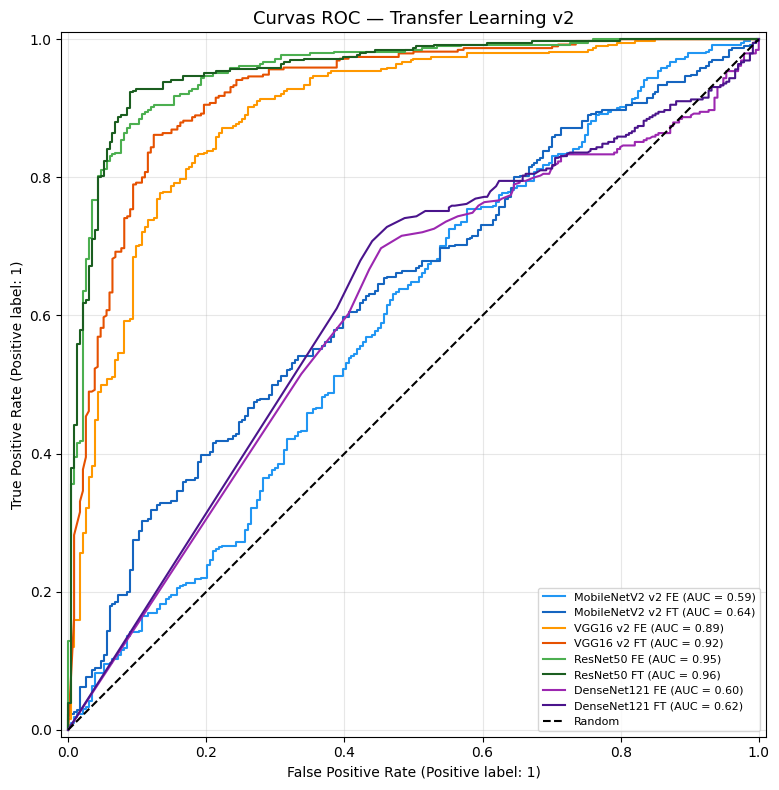

In [ ]:
# ─── TABLA COMPARATIVA ─────────────────────────────────────────────────────
# Referencia: resultados del notebook anterior (TransferLearningImagen)
prev_results = {
    'CNN v1 (from scratch)':          {'accuracy': 0.90,   'auc': 0.9555, 'sens': 0.9359, 'spec': 0.8376, 'fn': 25},
    'VGG16 FE (v1)':                  {'accuracy': 0.8237, 'auc': 0.8820, 'sens': 0.8462, 'spec': 0.7863, 'fn': 60},
    'VGG16 FT block5 (v1)':           {'accuracy': 0.8253, 'auc': 0.8816, 'sens': 0.8692, 'spec': 0.7521, 'fn': 51},
    'MobileNetV2 FE preprocess (v1)': {'accuracy': 0.5753, 'auc': 0.6974, 'sens': 0.4487, 'spec': 0.7863, 'fn': 215},
    'MobileNetV2 FT preprocess (v1)': {'accuracy': 0.6202, 'auc': 0.6898, 'sens': 0.5667, 'spec': 0.7094, 'fn': 169},
}
all_results = {**prev_results, **results_v2}

print(f"\n{'='*80}")
print(f"{'Modelo':<36} {'Accuracy':>9} {'AUC-ROC':>8} {'Sensib.':>8} {'Especif.':>9} {'FN':>5}")
print(f"{'='*80}")
separators = ['CNN v1 (from scratch)', 'MobileNetV2_v2 FE']
for name, m in all_results.items():
    if name in separators:
        print(f"{'─'*80}")
    print(f"{name:<36} {m['accuracy']:>9.4f} {m['auc']:>8.4f} "
          f"{m['sens']:>8.4f} {m['spec']:>9.4f} {int(m['fn']):>5}")
print(f"{'='*80}")

# ─── ROC CURVES v2 ────────────────────────────────────────────────────────
score_map = {
    'MobileNetV2 v2 FE': score_mob2_fe,
    'MobileNetV2 v2 FT': score_mob2_ft,
    'VGG16 v2 FE':       score_vgg2_fe,
    'VGG16 v2 FT':       score_vgg2_ft,
    'ResNet50 FE':       score_res_fe,
    'ResNet50 FT':       score_res_ft,
    'DenseNet121 FE':    score_dense_fe,
    'DenseNet121 FT':    score_dense_ft,
}
colors = ['#2196F3','#1565C0','#FF9800','#E65100','#4CAF50','#1B5E20','#9C27B0','#4A148C']

fig, ax = plt.subplots(figsize=(9, 8))
for (name, score), color in zip(score_map.items(), colors):
    RocCurveDisplay.from_predictions(y_test, score, name=name, color=color, ax=ax)
ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_title("Curvas ROC — Transfer Learning v2", fontsize=13)
ax.legend(loc='lower right', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusiones — Comparativa global Transfer Learning v1 vs v2

> **Nota**: Los resultados que figuran a continuación corresponden a la evaluación sobre el **conjunto de test** (624 imágenes), no a las métricas de entrenamiento.

### Tabla resumen completa (métricas sobre test set)

| Modelo | Accuracy | AUC-ROC | Sensibilidad | Especificidad | FN |
|--------|:--------:|:-------:|:------------:|:-------------:|:--:|
| **CNN v1 (from scratch)** — *línea base* | 0.9000 | 0.9555 | 0.9359 | 0.8376 | 25 |
| | | | | | |
| MobileNetV2 FE — `preprocess_input` **(v1)** | 0.5753 | 0.6974 | 0.4487 | 0.7863 | 215 |
| MobileNetV2 FT — `preprocess_input` **(v1)** | 0.6202 | 0.6898 | 0.5667 | 0.7094 | 169 |
| MobileNetV2 v2 FE — norm. simple `[0,1]` | 0.6300 | 0.5897 | 1.0000 | 0.0085 | 0 |
| MobileNetV2 v2 FT — norm. simple `[0,1]` | 0.6300 | 0.6352 | 0.9385 | 0.1068 | 24 |
| | | | | | |
| VGG16 FE — block5 **(v1)** | 0.8237 | 0.8820 | 0.8462 | 0.7863 | 60 |
| VGG16 FT — block5 **(v1)** | 0.8253 | 0.8816 | 0.8692 | 0.7521 | 51 |
| VGG16 v2 FE — block4+block5 | 0.7820 | 0.8921 | 0.9744 | 0.4615 | 10 |
| VGG16 v2 FT — block4+block5 | 0.7900 | 0.9234 | 0.9821 | 0.4573 | 7 |
| | | | | | |
| ResNet50 FE | 0.8830 | 0.9517 | 0.8615 | 0.9188 | 54 |
| **ResNet50 FT** | **0.9010** | **0.9555** | **0.9282** | **0.8632** | **28** |
| | | | | | |
| DenseNet121 FE | 0.6250 | 0.6044 | 1.0000 | 0.0000 | 0 |
| DenseNet121 FT | 0.6250 | 0.6186 | 1.0000 | 0.0000 | 0 |

---

### Análisis por experimento

#### Experimento 1 — MobileNetV2 con normalización simple — Hipótesis NO confirmada

Cambiar el preprocesado de `mobilenetv2_preprocess` (rango [-1, 1]) a normalización simple [0, 1] **no mejoró** el rendimiento en test. Ambas versiones colapsan:

- **v2 FE**: el modelo predice casi siempre PNEUMONIA (especificidad ≈ 0), AUC 0.5897 — **peor que v1** (0.6974)
- **v2 FT**: mejora levemente la especificidad (0.1068) pero sigue sin funcionar bien (AUC 0.6352 vs 0.6898 en v1)

El problema de MobileNetV2 con imágenes médicas va más allá del preprocesado: existe un desajuste profundo entre los filtros de ImageNet y las texturas de las radiografías en escala de grises, que no se resuelve solo cambiando la normalización.

#### Experimento 2 — VGG16 con Fine-Tuning extendido — Mejora parcial

Descongelar `block4 + block5` mejora el **AUC-ROC** respecto a v1 (+1 punto en FE, +4 puntos en FT), pero a costa de una **especificidad muy baja** (~0.46). El modelo detecta casi todos los enfermos pero genera muchos falsos positivos, siendo útil solo como herramienta de cribado inicial.

- **AUC-ROC FT**: 0.8816 (v1) → **0.9234** (v2), mejora de +4 puntos
- **Especificidad FT**: 0.7521 (v1) → **0.4573** (v2), retroceso notable

#### Experimento 3 — ResNet50 — Mejor modelo de Transfer Learning

ResNet50 FT es el único modelo de Transfer Learning que **iguala a la CNN entrenada desde cero** (AUC 0.9555 en ambos), con un equilibrio entre sensibilidad y especificidad muy cercano:

- **AUC-ROC**: 0.9555 (igual que CNN scratch)
- **Sensibilidad**: 0.9282 (vs 0.9359 CNN scratch)
- **Especificidad**: 0.8632 (vs 0.8376 CNN scratch) — incluso superior
- **FN**: 28 (vs 25 CNN scratch)

Las *skip connections* de ResNet facilitan el flujo de gradiente durante el fine-tuning, adaptando mejor las representaciones al dominio radiológico que VGG16 o MobileNetV2.

#### Experimento 4 — DenseNet121 — Colapso total

DenseNet121 colapsa en ambas variantes (FE y FT), prediciendo **siempre PNEUMONIA** sobre el conjunto de test (especificidad = 0.0000, FN = 0 pero infinitos falsos positivos). A pesar de mostrar buenas métricas durante el entrenamiento, el modelo no generaliza.

Esto indica **overfitting severo**: las *dense connections*, que conectan cada capa con todas las anteriores, favorecen la memorización del conjunto de entrenamiento en lugar de aprender representaciones generalizables cuando el dataset es pequeño y el dominio difiere mucho de ImageNet.

---

### Conclusión general

La versión v2 aporta aprendizajes importantes pero **no supera globalmente a la CNN entrenada desde cero**:

1. **ResNet50 FT iguala a la CNN from scratch** (AUC 0.9555), siendo el mejor resultado obtenido mediante Transfer Learning en toda la experimentación. Las skip connections facilitan la adaptación al dominio médico mejor que otras arquitecturas.

2. **La hipótesis de MobileNetV2 no se confirma**: cambiar la normalización no resuelve el problema de fondo. MobileNetV2 colapsa prediciendo la clase mayoritaria (PNEUMONIA), lo que sugiere que su backbone no extrae features útiles para este tipo de imágenes.

3. **DenseNet121 no es adecuado** en esta configuración: el overfitting es total. Podría beneficiarse de técnicas de regularización más agresivas (dropout, weight decay) o de preentrenamiento específico en datos radiológicos.

4. **VGG16 v2 mejora en AUC pero pierde especificidad**: descongelar más capas empuja al modelo a aumentar la sensibilidad a costa de los falsos positivos. No es la estrategia óptima de fine-tuning para este dominio.

5. **El domain gap sigue siendo el obstáculo principal**: una CNN entrenada directamente sobre los datos (sin ImageNet) sigue siendo competitiva porque no arrastra el sesgo de las imágenes naturales. La solución definitiva pasaría por modelos preentrenados en datasets radiológicos (p. ej. CheXNet).

---

### Líneas de mejora futuras

- **Backbones preentrenados en datos médicos**: CheXNet (DenseNet-121 en CheXpert/ChestX-ray14) o BioViL para radiografías.
- **Regularización más fuerte para DenseNet121**: dropout, label smoothing, weight decay más agresivo.
- **Data augmentation específico para radiografías**: variaciones de contraste, ruido gaussiano, transformaciones elásticas.
- **Ajuste de umbral de decisión**: en lugar de clasificar con threshold 0.5, optimizar el umbral según la curva ROC para maximizar la sensibilidad manteniendo una especificidad clínicamente aceptable.
- **Ensemble ResNet50 FT + VGG16 v2 FT**: combinar la especificidad de ResNet50 con la sensibilidad de VGG16 v2.